# Marked Spatial Point Process — From Scratch and With NumPyro

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/xtremax/blob/main/docs/notebooks/marked_spatial_from_scratch_and_numpyro.ipynb)

A **marked spatial point process** pairs each event location with a *mark* — a magnitude, type, size, or any other random attribute attached to the point. Common examples:

* tree locations + diameters,
* earthquake epicentres + magnitudes (Gutenberg–Richter),
* crime events + severity codes,
* methane plumes + emission rates.

Under the **separable factorisation** $\lambda(s, m) = \lambda(s)\, f(m \mid s)$, the joint log-likelihood splits into a ground-process term and a mark term:

$$\log L = \sum_{i=1}^n \log \lambda(s_i) + \sum_{i=1}^n \log f(m_i \mid s_i) - \Lambda(D).$$

`xtremax`'s `MarkedSpatialPP` is exactly this: a ground operator (homogeneous or inhomogeneous spatial PP) plus a user-supplied mark distribution callable. Marks can be scalar, vector, discrete, or location-dependent — anything a `numpyro.distributions.Distribution` can express.

## Setup

In [1]:
%pip install -q xtremax matplotlib  # uncomment on Colab
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
from jax import random
from numpyro.infer import MCMC, NUTS

from xtremax.point_processes import RectangularDomain
from xtremax.point_processes.distributions import (
    MarkedSpatialPP as MarkedSpatialDist,
)
from xtremax.point_processes.operators import (
    HomogeneousSpatialPP,
    InhomogeneousSpatialPP,
    MarkedSpatialPP,
)


plt.rcParams["figure.figsize"] = (8.0, 4.0)

/home/azureuser/localfiles/xtremax/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


/home/azureuser/localfiles/xtremax/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Independent marks: trees with random diameters

The simplest marked process: locations from a homogeneous spatial PP, marks i.i.d. Gamma. The mark distribution callable ignores its input and just returns the same `Gamma` for every event.

In [2]:
domain = RectangularDomain.from_size(jnp.array([10.0, 10.0]))  # 10m × 10m plot
ground = HomogeneousSpatialPP(rate=0.5, domain=domain)
diameter_dist = dist.Gamma(concentration=5.0, rate=2.0)  # mean = 2.5, variance = 1.25

trees = MarkedSpatialPP(
    ground=ground,
    mark_distribution_fn=lambda s: diameter_dist,  # location-independent
)

locs, mask, diameters = trees.sample(random.PRNGKey(0), max_events=128)
print(
    f"Sampled {int(mask.sum())} trees, mean diameter = {float(jnp.mean(diameters[mask])):.2f} m"
)

Sampled 38 trees, mean diameter = 2.59 m


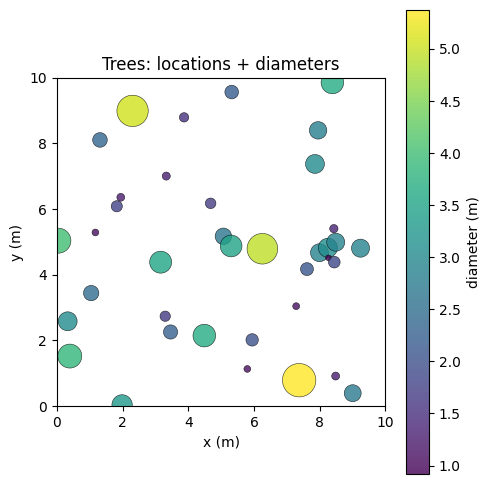

In [3]:
fig, ax = plt.subplots(figsize=(5, 5))
real_locs = locs[mask]
real_diameters = diameters[mask]
sc = ax.scatter(
    real_locs[:, 0],
    real_locs[:, 1],
    s=20 * real_diameters**2,
    c=real_diameters,
    cmap="viridis",
    alpha=0.8,
    edgecolors="black",
    linewidth=0.4,
)
plt.colorbar(sc, label="diameter (m)")
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect("equal")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Trees: locations + diameters")
plt.tight_layout()
plt.show()

The joint log-likelihood decomposes — and we can score the ground and mark terms separately.

In [4]:
joint_lp = trees.log_prob(locs, mask, diameters)
ground_lp = trees.ground_log_prob(locs, mask)
marks_lp = trees.marks_log_prob(locs, diameters, mask)
print(
    f"joint log L = {float(joint_lp):.2f}  =  ground {float(ground_lp):.2f} + marks {float(marks_lp):.2f}"
)
assert jnp.allclose(joint_lp, ground_lp + marks_lp)

joint log L = -308.11  =  ground -251.34 + marks -56.77


## 2. Location-dependent marks: earthquakes along a fault line

Now make the mark law depend on space. Earthquake magnitudes follow Gutenberg–Richter — Exponential with a $b$-value parameter — but suppose the $b$-value is smaller (heavier-tailed magnitudes) closer to the fault. We'll use an inhomogeneous spatial PP whose intensity is concentrated along a diagonal fault, and an Exponential mark with rate inversely proportional to distance from that fault.

In [5]:
fault_domain = RectangularDomain.from_size(jnp.array([100.0, 100.0]))  # 100km × 100km


def fault_log_intensity(s):
    # Fault line: y = x. Distance from the line: |x - y| / √2.
    dist_to_fault = jnp.abs(s[..., 0] - s[..., 1]) / jnp.sqrt(2.0)
    # Higher rate near the fault.
    return jnp.log(0.05 + 0.5 * jnp.exp(-0.05 * dist_to_fault))


fault_pp = InhomogeneousSpatialPP(
    fault_log_intensity, fault_domain, lambda_max=0.55, n_integration_points=4096
)


def magnitude_dist(s):
    # b-value smaller (higher-magnitude events more likely) near the fault.
    dist_to_fault = jnp.abs(s[0] - s[1]) / jnp.sqrt(2.0)
    b_value = (
        1.0 + 0.5 * dist_to_fault / 50.0
    )  # b ranges from 1 (on fault) to ~1.7 (far)
    return dist.Exponential(rate=b_value)


earthquakes = MarkedSpatialPP(
    ground=fault_pp,
    mark_distribution_fn=magnitude_dist,
)

eq_locs, eq_mask, eq_mags = earthquakes.sample(random.PRNGKey(2), max_events=2048)
print(
    f"Sampled {int(eq_mask.sum())} earthquakes, max magnitude = {float(jnp.max(eq_mags)):.2f}"
)

Sampled 932 earthquakes, max magnitude = 7.03


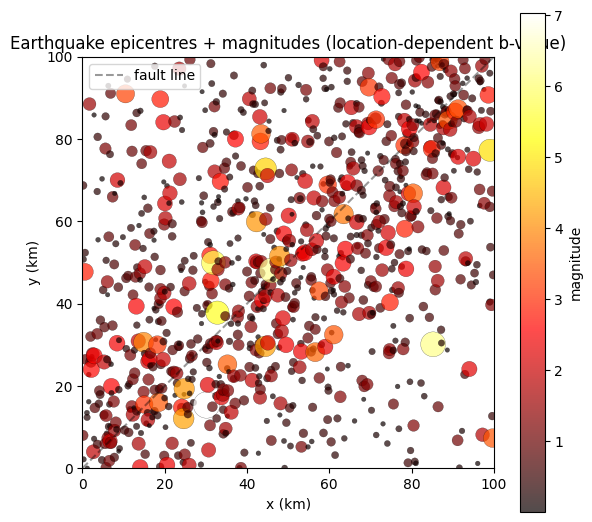

In [6]:
fig, ax = plt.subplots(figsize=(6, 5.5))
real_eq_locs = eq_locs[eq_mask]
real_mags = eq_mags[eq_mask]
sc = ax.scatter(
    real_eq_locs[:, 0],
    real_eq_locs[:, 1],
    s=10 + 50 * real_mags,
    c=real_mags,
    cmap="hot",
    alpha=0.7,
    edgecolors="black",
    linewidth=0.2,
)
plt.colorbar(sc, label="magnitude")
# Overlay the fault line.
ax.plot([0, 100], [0, 100], "k--", alpha=0.4, label="fault line")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_aspect("equal")
ax.set_xlabel("x (km)")
ax.set_ylabel("y (km)")
ax.set_title("Earthquake epicentres + magnitudes (location-dependent b-value)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

Sanity check: events near the fault should have higher mean magnitude than events far from it (lower b-value → heavier tail).

In [7]:
real_dists = jnp.abs(real_eq_locs[:, 0] - real_eq_locs[:, 1]) / jnp.sqrt(2.0)
near_fault = real_mags[real_dists < 10.0]
far_fault = real_mags[real_dists > 30.0]
print(f"Mean magnitude within 10 km of fault: {float(jnp.mean(near_fault)):.3f}")
print(f"Mean magnitude beyond 30 km of fault: {float(jnp.mean(far_fault)):.3f}")

Mean magnitude within 10 km of fault: 0.851
Mean magnitude beyond 30 km of fault: 0.695


## 3. With NumPyro — joint inference over ground rate and mark scale

Treat both the ground rate $\lambda$ and the mark scale parameter as latent. The joint log-likelihood means a single NUTS run gives us a coherent posterior over both.

In [8]:
true_rate = 0.4
true_concentration = 4.0
true_mark_rate = 1.5
ground_synth = HomogeneousSpatialPP(rate=true_rate, domain=domain)
mark_synth = dist.Gamma(concentration=true_concentration, rate=true_mark_rate)
synth_pp = MarkedSpatialPP(
    ground=ground_synth, mark_distribution_fn=lambda s: mark_synth
)
obs_locs, obs_mask, obs_marks = synth_pp.sample(random.PRNGKey(0), max_events=128)
print(f"Synthetic observation: {int(obs_mask.sum())} events")

Synthetic observation: 29 events


In [9]:
# Score via ``numpyro.factor`` since the observation is a heterogeneous
# PyTree ``(locations, mask, marks)`` rather than a single array.
def model():
    rate = numpyro.sample("rate", dist.LogNormal(0.0, 1.0))
    mark_concentration = numpyro.sample(
        "mark_concentration", dist.LogNormal(jnp.log(4.0), 0.5)
    )
    mark_rate = numpyro.sample("mark_rate", dist.LogNormal(jnp.log(1.5), 0.5))

    ground = HomogeneousSpatialPP(rate=rate, domain=domain)
    mpp = MarkedSpatialDist(
        ground=ground,
        mark_distribution_fn=lambda s: dist.Gamma(
            concentration=mark_concentration, rate=mark_rate
        ),
        max_events=128,
    )
    numpyro.factor("lik", mpp.log_prob((obs_locs, obs_mask, obs_marks)))


mcmc = MCMC(NUTS(model), num_warmup=500, num_samples=1000, progress_bar=False)
mcmc.run(random.PRNGKey(0))
mcmc.print_summary()


                          mean       std    median      5.0%     95.0%     n_eff     r_hat
  mark_concentration      4.06      0.89      3.99      2.78      5.60    291.15      1.00
           mark_rate      1.42      0.33      1.39      0.89      1.91    293.28      1.00
                rate      0.30      0.06      0.30      0.21      0.39    539.76      1.00

Number of divergences: 0


All three posteriors should concentrate near the truth. The ground rate is informed only by the count, the Gamma parameters only by the magnitudes — the *separable* factorisation makes each subset of parameters an essentially independent posterior block (modulo whatever prior coupling we impose).

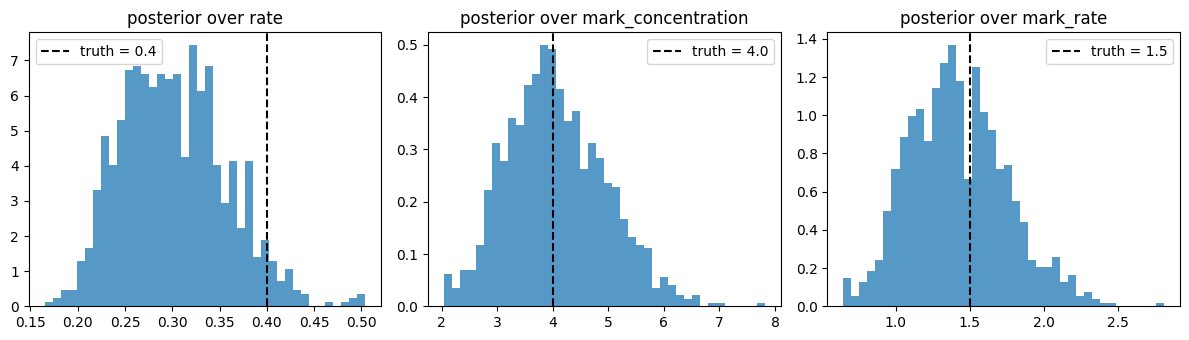

In [10]:
samples = mcmc.get_samples()
truths = {
    "rate": true_rate,
    "mark_concentration": true_concentration,
    "mark_rate": true_mark_rate,
}
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, name in zip(axes, ("rate", "mark_concentration", "mark_rate"), strict=False):
    ax.hist(samples[name], bins=40, alpha=0.75, density=True)
    ax.axvline(truths[name], color="k", linestyle="--", label=f"truth = {truths[name]}")
    ax.set_title(f"posterior over {name}")
    ax.legend()
plt.tight_layout()
plt.show()

## Where to go from here

- **Vector or discrete marks.** Swap the mark distribution for `MultivariateNormal` (vector marks), `Categorical` (event types), or `Pareto` (heavy-tailed magnitudes). The factorisation and the API don't change.
- **Joint posterior over intensity *and* mark hyperparameters.** Using `InhomogeneousSpatialPP` as the ground process, you can infer both the spatial peak location and a magnitude-decay rate in a single NUTS run.
- **Higher dimensions.** As with the unmarked spatial PPs, mark inference works for $d \in \{1, 2, 3, \ldots\}$ — the mark distribution callable just consumes the location's full $d$-vector.